In [1]:
import pandas as pd
import numpy as np

FILE = 'ThesisSharondeBondt_SystematicReview_RawData_v7_20260303.xlsx'

df_raw = pd.read_excel(FILE, sheet_name='Data')

print(f"Shape: {df_raw.shape}")
print(f"Fully empty rows: {df_raw.isna().all(axis=1).sum()}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Shape: (625, 112)
Fully empty rows: 403
Columns: ['Article_ID', 'Authors', 'Title', 'Year', 'journal', 'DOI', 'Included_after_screening', 'Quality_score', 'Exclusion_reason', 'Polymer_name', 'Polymer_type', 'Material_family', 'Biobased', 'Biodegradable', 'Additives_present', 'Additives_concentration_wt%', 'Processing_method', 'Film_thickness_µm', 'Film_thickness_SD_µm', 'Film_thickness_replicates', 'PO2_value', 'PO2_SD', 'PO2_unit', 'PO2_conversion_factor', 'PO2_cm³·µm·m⁻²·d⁻¹·bar⁻¹ ', 'PO2_SD_cm³·µm·m⁻²·d⁻¹·bar⁻¹ ', 'PO2_standard', 'PO2_temperature_°C', 'PO2_RH_%', 'OTR_value', 'OTR_SD', 'OTR_unit', 'OTR_conversion_factor', 'OTR100_cm3·m-2·d-1·bar-1', 'OTR100_SD_cm3·m-2·d-1·bar-1', 'OTR_standard', 'OTR_temperature_°C', 'OTR_RH_%', 'PCO2_value', 'PCO2_SD', 'PCO2_unit', 'PCO2_conversion_factor', 'PCO2_cm³·µm·m⁻²·d⁻¹·bar⁻¹ ', 'PCO2_SD_cm³·µm·m⁻²·d⁻¹·bar⁻¹ ', 'PCO2_standard', 'PCO2_temperature_°C', 'PCO2_RH_%', 'CO2TR100_cm3·m-2·d-1·bar-1', 'CO2TR100_SD_cm3·m-2·d-1·bar-1', 'CO2TR_standard

,Article_ID,Authors,Title,Year,journal,DOI,Included_after_screening,Quality_score,Exclusion_reason,Polymer_name,...,Reference_WVTR_value,Reference_WVTR_unit,Reference_WVTR_conversion_factor,Reference_WVTR100_g·m-2·d-1,Reference_WVTR_T_°C,Reference_WVTR_RH_%,Comparison_type,Food_contact_tested,Key_barrier_finding,Reviewer_notes
0,2.0,"Demchenko, H.; Knaapila, M.",Bio-Based Coatings and Free-Standing Films fro...,2025.0,European journal of Lipid Science and Technology,10.1002/ejlt.70091,No,NaN,"Test conditions (T, RH, thickness) for barrier...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,"Coltelli, M.-B.; Cartoni, F.; Panariello, L.; ...",Assessing PLA/PBSA Films for Sustainable Packa...,2025.0,Polymers,10.3390/polym17233093,No,NaN,"Test conditions (T, RH, thickness) for barrier...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,"Tassew, N.A.; Andualem, T.L.; Reddy Prasad, R....",Avocado seed starch bioplastic film reinforced...,2025.0,Scientific Reports,10.1038/s41598-025-24935-3,No,NaN,"Test conditions (T, RH, thickness) for barrier...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# CLEAN: remove fully empty rows
df = df_raw.dropna(how='all').reset_index(drop=True)

# VERIFY
print(f"Before: {df_raw.shape}")
print(f"After:  {df.shape}")
print(f"Rows removed: {len(df_raw) - len(df)}")
print(f"\nAny fully empty rows remaining? {df.isna().all(axis=1).any()}")
print(f"\nFirst 3 rows preview:")
df[['Article_ID', 'Authors', 'Polymer_name', 'Included_after_screening']].head(3)

Before: (625, 112)
After:  (222, 112)
Rows removed: 403

Any fully empty rows remaining? False

First 3 rows preview:


,Article_ID,Authors,Polymer_name,Included_after_screening
0,2.0,"Demchenko, H.; Knaapila, M.",NaN,No
1,3.0,"Coltelli, M.-B.; Cartoni, F.; Panariello, L.; ...",NaN,No
2,4.0,"Tassew, N.A.; Andualem, T.L.; Reddy Prasad, R....",NaN,No


In [3]:
# CLEAN: strip whitespace from column names
df.columns = df.columns.str.strip()

# Strip leading/trailing spaces from all string columns
str_cols = df.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    df[col] = df[col].str.strip()

# VERIFY
print(f"String columns cleaned: {len(str_cols)}")
print(f"\nColumn names with spaces (should be 0): {sum(1 for c in df.columns if c != c.strip())}")

# Spot-check: show unique values in a few key columns to confirm no stray spaces
for col in ['Included_after_screening', 'Biobased', 'Biodegradable', 'Processing_method']:
    print(f"\n{col}: {sorted(df[col].dropna().unique().tolist())}")

String columns cleaned: 36

Column names with spaces (should be 0): 0

Included_after_screening: ['No', 'Yes']

Biobased: ['No', 'Yes']

Biodegradable: ['Yes']

Processing_method: ['Casting', 'Compression molding', 'Extrusion']


In [4]:
# INSPECT: show all unique values for categorical columns
categorical_cols = [
    'Polymer_type', 'Material_family', 'Biobased', 'Biodegradable',
    'Additives_present', 'Processing_method', 'Included_after_screening',
    'Exclusion_reason', 'Comparison_type', 'PO2_standard', 'OTR_standard',
    'PCO2_standard', 'CO2TR_standard', 'WVP_standard', 'WVTR_standard'
]

for col in categorical_cols:
    if col in df.columns:
        vals = sorted(df[col].dropna().unique().tolist())
        print(f"\n{col} ({len(vals)} unique):")
        for v in vals:
            print(f"   '{v}'")


Polymer_type (15 unique):
   'Cellulose derivative'
   'Chitosan'
   'Furanoate polyester'
   'Gelatin'
   'Hemicellulose'
   'PBS'
   'PBSA'
   'PHBV'
   'PLA'
   'PVA'
   'Pectin'
   'Plant protein'
   'Pullulan'
   'Starch'
   'Whey'

Material_family (5 unique):
   'Aliphatic biopolyester'
   'Aromatic biopolyester'
   'Polysaccharide'
   'Protein'
   'Vinyl biopolymer'

Biobased (2 unique):
   'No'
   'Yes'

Biodegradable (1 unique):
   'Yes'

Additives_present (5 unique):
   'Fructose'
   'Glycerol'
   'Sorbitol'
   'Sorbitol; Benzalkonium chloride'
   'Xylitol'

Processing_method (3 unique):
   'Casting'
   'Compression molding'
   'Extrusion'

Included_after_screening (2 unique):
   'No'
   'Yes'

Exclusion_reason (4 unique):
   'Multilayer, composite or active packaging material'
   'Not a polymeric material'
   'QS < 0.8'
   'Test conditions (T, RH, thickness) for barrier properties not recorded'

Comparison_type (2 unique):
   'Direct in same study'
   'Literature benchmark'

In [5]:
# INSPECT: check for capitalization inconsistencies
# (same word in different cases, e.g. 'casting' vs 'Casting')
from collections import defaultdict

str_cols = df.select_dtypes(include='object').columns.tolist()

found_conflicts = False
for col in str_cols:
    vals = df[col].dropna().unique()
    groups = defaultdict(list)
    for v in vals:
        groups[str(v).lower()].append(v)
    conflicts = {k: v for k, v in groups.items() if len(v) > 1}
    if conflicts:
        found_conflicts = True
        print(f"\n⚠️  {col}:")
        for variants in conflicts.values():
            print(f"   {variants}")

if not found_conflicts:
    print("✅ No capitalization conflicts found!")

✅ No capitalization conflicts found!


In [6]:
# INSPECT: check which columns should be numeric but aren't
expected_numeric = [c for c in df.columns if any(kw in c for kw in
    ['_value', '_SD', 'temperature', 'RH_%', 'thickness', 'replicates',
     'conversion_factor', 'score', 'Year', '_bar', 'factor', '_µm',
     'Article_ID', 'psat', 'Replicates', 'wt%'])]

print(f"Columns expected to be numeric: {len(expected_numeric)}\n")
print(f"{'Column':<50} {'Current dtype':<15} {'Non-numeric values'}")
print("-" * 90)
for col in expected_numeric:
    if col in df.columns:
        dtype = str(df[col].dtype)
        if df[col].dtype == object:
            # Show any values that can't be converted
            non_numeric = pd.to_numeric(df[col], errors='coerce')
            bad_vals = df.loc[non_numeric.isna() & df[col].notna(), col].unique().tolist()
            print(f"{col:<50} {dtype:<15} ⚠️  {bad_vals}")
        else:
            print(f"{col:<50} {dtype:<15} ✅")

Columns expected to be numeric: 64

Column                                             Current dtype   Non-numeric values
------------------------------------------------------------------------------------------
Article_ID                                         float64         ✅
Year                                               float64         ✅
Quality_score                                      float64         ✅
Additives_concentration_wt%                        object          ⚠️  ['40; 0.23%', '40; 0.5%', '40; 0.75%']
Film_thickness_µm                                  float64         ✅
Film_thickness_SD_µm                               float64         ✅
Film_thickness_replicates                          float64         ✅
PO2_value                                          float64         ✅
PO2_SD                                             float64         ✅
PO2_conversion_factor                              float64         ✅
PO2_SD_cm³·µm·m⁻²·d⁻¹·bar⁻¹                        float

In [7]:
# FIX 1: WVTR_SD — replace 'Not specified' with NaN, then convert to float
df['WVTR_SD'] = df['WVTR_SD'].replace('Not specified', np.nan)
df['WVTR_SD'] = pd.to_numeric(df['WVTR_SD'], errors='coerce')

# FIX 2: Additives_concentration_wt% — leave as text (mixed values), just clean % signs
df['Additives_concentration_wt%'] = df['Additives_concentration_wt%'].str.replace('%', '', regex=False).str.strip()

# FIX 3: Article_ID and Year should be integers, not floats
df['Article_ID'] = df['Article_ID'].astype('Int64')
df['Year'] = df['Year'].astype('Int64')

# VERIFY
print(f"WVTR_SD dtype: {df['WVTR_SD'].dtype}")
print(f"WVTR_SD non-numeric remaining: {df['WVTR_SD'].dropna()[pd.to_numeric(df['WVTR_SD'], errors='coerce').isna()].tolist()}")
print(f"\nArticle_ID dtype: {df['Article_ID'].dtype}  — sample: {df['Article_ID'].head(3).tolist()}")
print(f"Year dtype:       {df['Year'].dtype}  — unique: {sorted(df['Year'].dropna().unique().tolist())}")
print(f"\nAdditives_concentration_wt% sample:\n{df['Additives_concentration_wt%'].dropna().unique().tolist()}")

WVTR_SD dtype: float64
WVTR_SD non-numeric remaining: []

Article_ID dtype: Int64  — sample: [2, 3, 4]
Year dtype:       Int64  — unique: [2024, 2025]

Additives_concentration_wt% sample:
['40; 0.23', '40; 0.5', '40; 0.75']


C:\Users\Sharon de Bondt\AppData\Local\Temp\ipykernel_8940\959696683.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['WVTR_SD'] = df['WVTR_SD'].replace('Not specified', np.nan)



 BIOBASED MATERIALS  (N rows = 48)

  Film Thickness (µm)
  N=48, Q1=65.5, Q3=120, IQR=55, fences=[-17, 203]
  ⚠️  5 outlier(s):
 Article_ID Polymer_name  Film_thickness_µm  Lower_fence  Upper_fence
          5          PLA              390.0        -17.0        203.0
         34       Starch              250.0        -17.0        203.0
         55       Starch              270.0        -17.0        203.0
         71         PHBV              500.0        -17.0        203.0
         71         PBSA              500.0        -17.0        203.0

  OTR100 (cm³·m⁻²·d⁻¹·bar⁻¹)
  N=11, Q1=9.43, Q3=210, IQR=200, fences=[-291, 510]
  ⚠️  1 outlier(s):
 Article_ID Polymer_name  OTR100_cm3·m-2·d-1·bar-1  Lower_fence  Upper_fence
         71         PBSA                  687.9168    -290.6753     509.6052

  WVTR100 (g·m⁻²·d⁻¹)
  N=44, Q1=93.3, Q3=693, IQR=600, fences=[-807, 1.59e+03]
  ⚠️  9 outlier(s):
 Article_ID                              Polymer_name  WVTR100_g·m-2·d-1  Lower_fence  Upper

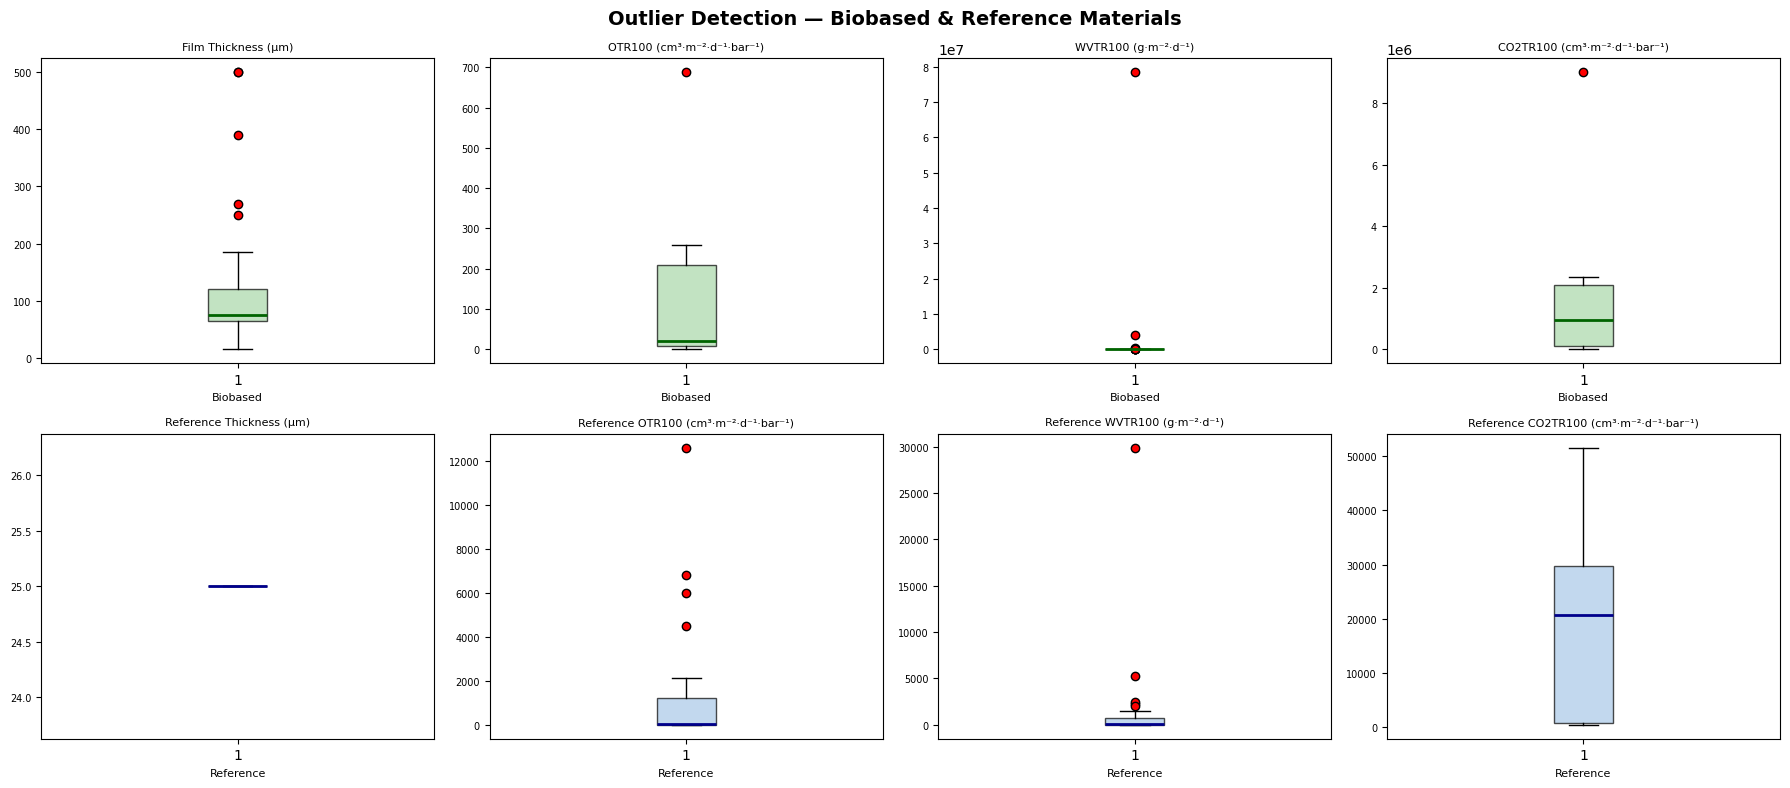


✅ Plot saved as 'outliers_boxplot.png'


In [8]:
import matplotlib.pyplot as plt

# Biobased filter for biobased columns
df_bio = df[df['Biobased'] == 'Yes'].copy()

# Reference data: no biobased filter — references are conventional materials
df_ref = df[df['Reference_polymer'].notna()].copy()

cols_bio = {
    'Film_thickness_µm': 'Film Thickness (µm)',
    'OTR100_cm3·m-2·d-1·bar-1': 'OTR100 (cm³·m⁻²·d⁻¹·bar⁻¹)',
    'WVTR100_g·m-2·d-1': 'WVTR100 (g·m⁻²·d⁻¹)',
    'CO2TR100_cm3·m-2·d-1·bar-1': 'CO2TR100 (cm³·m⁻²·d⁻¹·bar⁻¹)'
}

cols_ref = {
    'Reference_thickness_µm': 'Reference Thickness (µm)',
    'Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹': 'Reference OTR100 (cm³·m⁻²·d⁻¹·bar⁻¹)',
    'Reference_WVTR100_g·m-2·d-1': 'Reference WVTR100 (g·m⁻²·d⁻¹)',
    'Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹': 'Reference CO2TR100 (cm³·m⁻²·d⁻¹·bar⁻¹)'
}

# IQR outlier function
def get_outliers(series, col, df_source):
    s = series.dropna()
    if len(s) < 4:
        return pd.DataFrame()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    result = df_source.loc[mask, ['Article_ID', 'Reference_polymer' if 'Reference' in col else 'Polymer_name', col]].copy()
    result['Lower_fence'] = round(lower, 4)
    result['Upper_fence'] = round(upper, 4)
    return result

# Print outlier tables
for group_name, cols, df_used in [
    ('BIOBASED MATERIALS', cols_bio, df_bio),
    ('REFERENCE MATERIALS', cols_ref, df_ref)
]:
    print(f"\n{'='*60}")
    print(f" {group_name}  (N rows = {len(df_used)})")
    print(f"{'='*60}")
    for col, label in cols.items():
        if col not in df_used.columns:
            print(f"\n  ⚠️  Column not found: {col}")
            continue
        s = df_used[col].dropna()
        if len(s) < 4:
            print(f"\n  {label}")
            print(f"  ⚠️  Not enough data (N={len(s)})")
            continue
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        out = get_outliers(df_used[col], col, df_used)
        print(f"\n  {label}")
        print(f"  N={len(s)}, Q1={Q1:.3g}, Q3={Q3:.3g}, IQR={IQR:.3g}, fences=[{Q1-1.5*IQR:.3g}, {Q3+1.5*IQR:.3g}]")
        if out.empty:
            print(f"  ✅ No outliers")
        else:
            print(f"  ⚠️  {len(out)} outlier(s):")
            print(out.to_string(index=False))

# Boxplots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Outlier Detection — Biobased & Reference Materials', fontsize=14, fontweight='bold')

all_cols = list(cols_bio.items()) + list(cols_ref.items())
dataframes = [df_bio] * 4 + [df_ref] * 4
row_labels = ['Biobased'] * 4 + ['Reference'] * 4

for i, (ax, (col, label), df_used) in enumerate(zip(axes.flatten(), all_cols, dataframes)):
    if col not in df_used.columns:
        ax.set_visible(False)
        continue
    data = df_used[col].dropna()
    if len(data) < 2:
        ax.set_title(f"{label}\n(no data)", fontsize=8)
        ax.set_visible(True)
        continue
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#a8d8a8' if i < 4 else '#a8c8e8', alpha=0.7),
               medianprops=dict(color='darkgreen' if i < 4 else 'darkblue', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
    ax.set_title(label, fontsize=8, wrap=True)
    ax.set_xlabel(row_labels[i], fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved as 'outliers_boxplot.png'")

In [9]:
OUTPUT_FILE = 'ThesisSharondeBondt_SystematicReview_Cleaned.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Data_Cleaned', index=False)

print(f'✅ Cleaned data saved to: {OUTPUT_FILE}')
print(f'   Final shape: {df.shape}')

# Final summary
print(f"""
╔══════════════════════════════════════════╗
║         CLEANING SUMMARY                ║
╠══════════════════════════════════════════╣
║  Step 1 — Empty rows removed:  403      ║
║  Step 2 — String cols stripped:  35     ║
║  Step 3 — Spelling errors:    none      ║
║  Step 4 — Capital conflicts:  none      ║
║  Step 5 — Dtypes fixed:         3       ║
║           WVTR_SD → float64            ║
║           Article_ID → Int64           ║
║           Year → Int64                 ║
║  Step 6 — Outliers flagged & reviewed  ║
║           Data entry errors fixed       ║
║           in Excel for Art. 1,24,71    ║
╚══════════════════════════════════════════╝
""")

✅ Cleaned data saved to: ThesisSharondeBondt_SystematicReview_Cleaned.xlsx
   Final shape: (222, 112)

╔══════════════════════════════════════════╗
║         CLEANING SUMMARY                ║
╠══════════════════════════════════════════╣
║  Step 1 — Empty rows removed:  403      ║
║  Step 2 — String cols stripped:  35     ║
║  Step 3 — Spelling errors:    none      ║
║  Step 4 — Capital conflicts:  none      ║
║  Step 5 — Dtypes fixed:         3       ║
║           WVTR_SD → float64            ║
║           Article_ID → Int64           ║
║           Year → Int64                 ║
║  Step 6 — Outliers flagged & reviewed  ║
║           Data entry errors fixed       ║
║           in Excel for Art. 1,24,71    ║
╚══════════════════════════════════════════╝



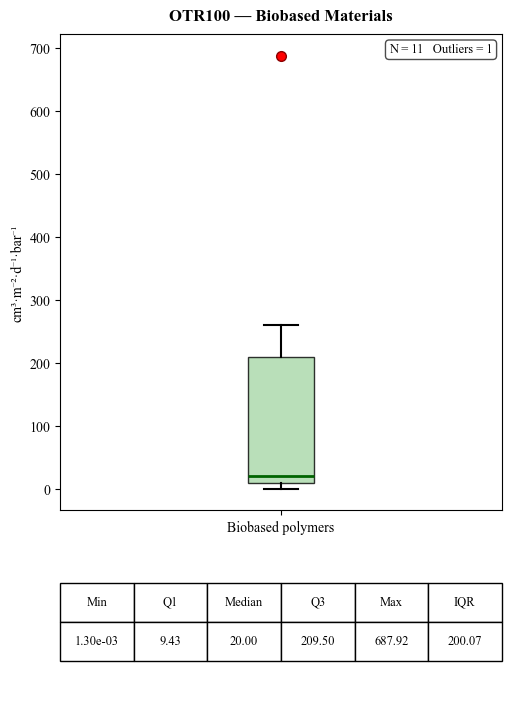

✅ Saved: visualisations_v7/boxplot_OTR100_biobased.png


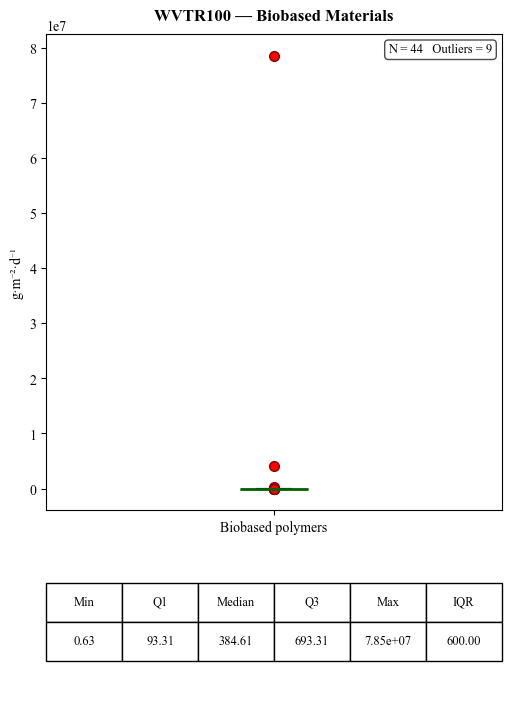

✅ Saved: visualisations_v7/boxplot_WVTR100_biobased.png


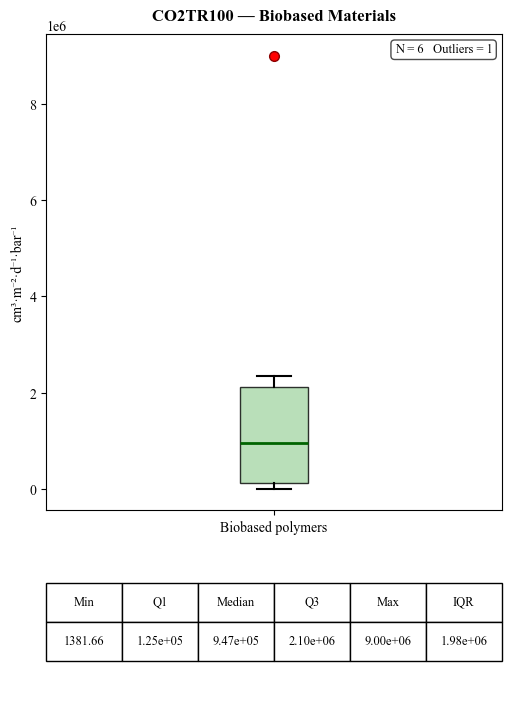

✅ Saved: visualisations_v7/boxplot_CO2TR100_biobased.png


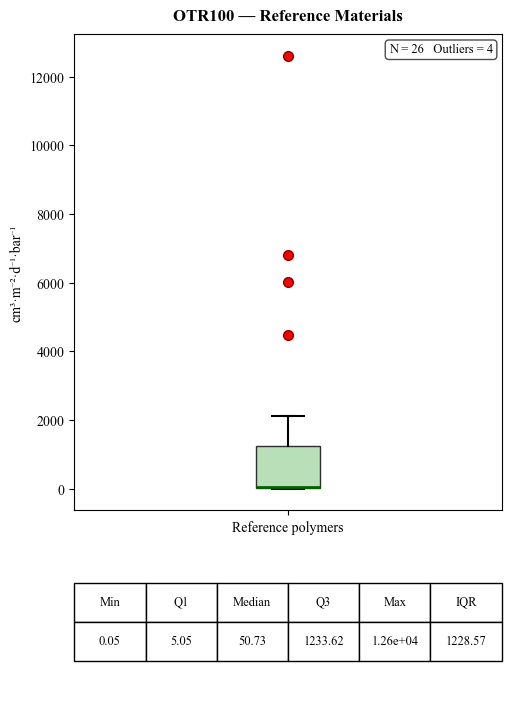

✅ Saved: visualisations_v7/boxplot_OTR100_reference.png


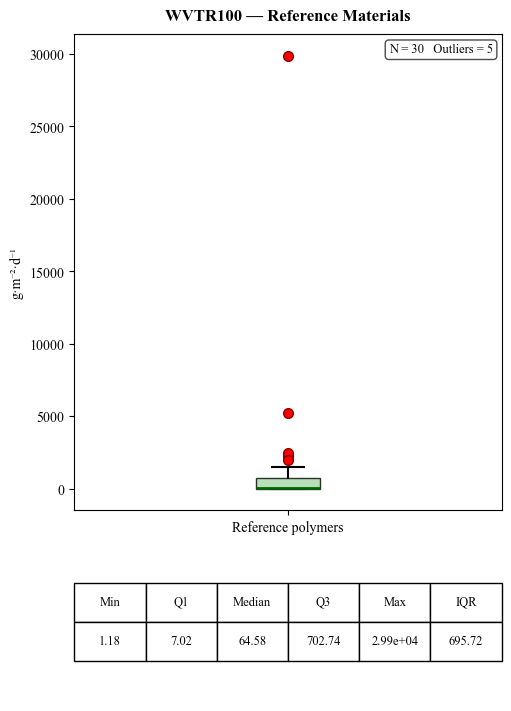

✅ Saved: visualisations_v7/boxplot_WVTR100_reference.png


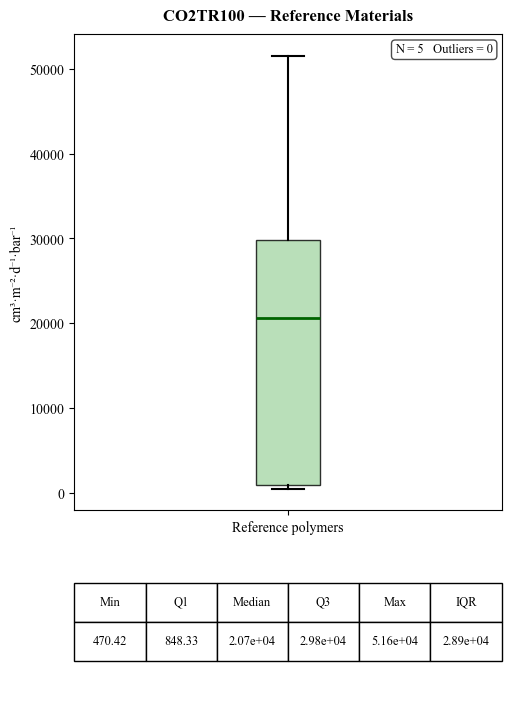

✅ Saved: visualisations_v7/boxplot_CO2TR100_reference.png

📁 All plots saved in: visualisations_v7/


In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

os.makedirs('visualisations_v7', exist_ok=True)
mpl.rcParams['font.family'] = 'Times New Roman'

df_bio = df[df['Biobased'] == 'Yes'].copy()
df_ref = df[df['Reference_polymer'].notna()].copy()

plots = [
    ('OTR100_cm3·m-2·d-1·bar-1',            'OTR100 — Biobased Materials',    'cm³·m⁻²·d⁻¹·bar⁻¹', 'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_OTR100_biobased.png'),
    ('WVTR100_g·m-2·d-1',                    'WVTR100 — Biobased Materials',   'g·m⁻²·d⁻¹',          'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_WVTR100_biobased.png'),
    ('CO2TR100_cm3·m-2·d-1·bar-1',           'CO2TR100 — Biobased Materials',  'cm³·m⁻²·d⁻¹·bar⁻¹', 'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_CO2TR100_biobased.png'),
    ('Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹',  'OTR100 — Reference Materials',   'cm³·m⁻²·d⁻¹·bar⁻¹', 'Reference polymers', df_ref, 'visualisations_v7/boxplot_OTR100_reference.png'),
    ('Reference_WVTR100_g·m-2·d-1',          'WVTR100 — Reference Materials',  'g·m⁻²·d⁻¹',          'Reference polymers', df_ref, 'visualisations_v7/boxplot_WVTR100_reference.png'),
    ('Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹', 'CO2TR100 — Reference Materials', 'cm³·m⁻²·d⁻¹·bar⁻¹', 'Reference polymers', df_ref, 'visualisations_v7/boxplot_CO2TR100_reference.png'),
]

for col, title, ylabel, xlabel, df_used, filepath in plots:
    if col not in df_used.columns:
        print(f'⚠️  Column not found: {col}')
        continue

    data = df_used[col].dropna()
    if len(data) < 2:
        print(f'⚠️  Not enough data for: {col}')
        continue

    # Stats
    Q1, Q3   = data.quantile(0.25), data.quantile(0.75)
    IQR      = Q3 - Q1
    median   = data.median()
    min_val  = data.min()
    max_val  = data.max()
    n_out    = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()

    fig, (ax_box, ax_stats) = plt.subplots(
        2, 1, figsize=(5, 7),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True
    )

    # Boxplot
    ax_box.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#a8d8a8', alpha=0.8),
                   medianprops=dict(color='darkgreen', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='red',
                                   markeredgecolor='darkred', markersize=7))
    ax_box.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(ylabel, fontsize=10)
    ax_box.set_xticks([1])
    ax_box.set_xticklabels([xlabel], fontsize=10)
    ax_box.text(0.98, 0.98, f'N = {len(data)}   Outliers = {n_out}',
                transform=ax_box.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Stats table below
    stats_labels = ['Min', 'Q1', 'Median', 'Q3', 'Max', 'IQR']
    stats_values = [min_val, Q1, median, Q3, max_val, IQR]

    # Format: use scientific notation if value > 10000
    def fmt(v):
        return f'{v:.2e}' if abs(v) > 10000 or (abs(v) < 0.01 and v != 0) else f'{v:.2f}'

    table_data = [[fmt(v) for v in stats_values]]
    table = ax_stats.table(
        cellText=table_data,
        colLabels=stats_labels,
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)
    ax_stats.axis('off')

    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {filepath}')

print(f'\n📁 All plots saved in: visualisations_v7/')

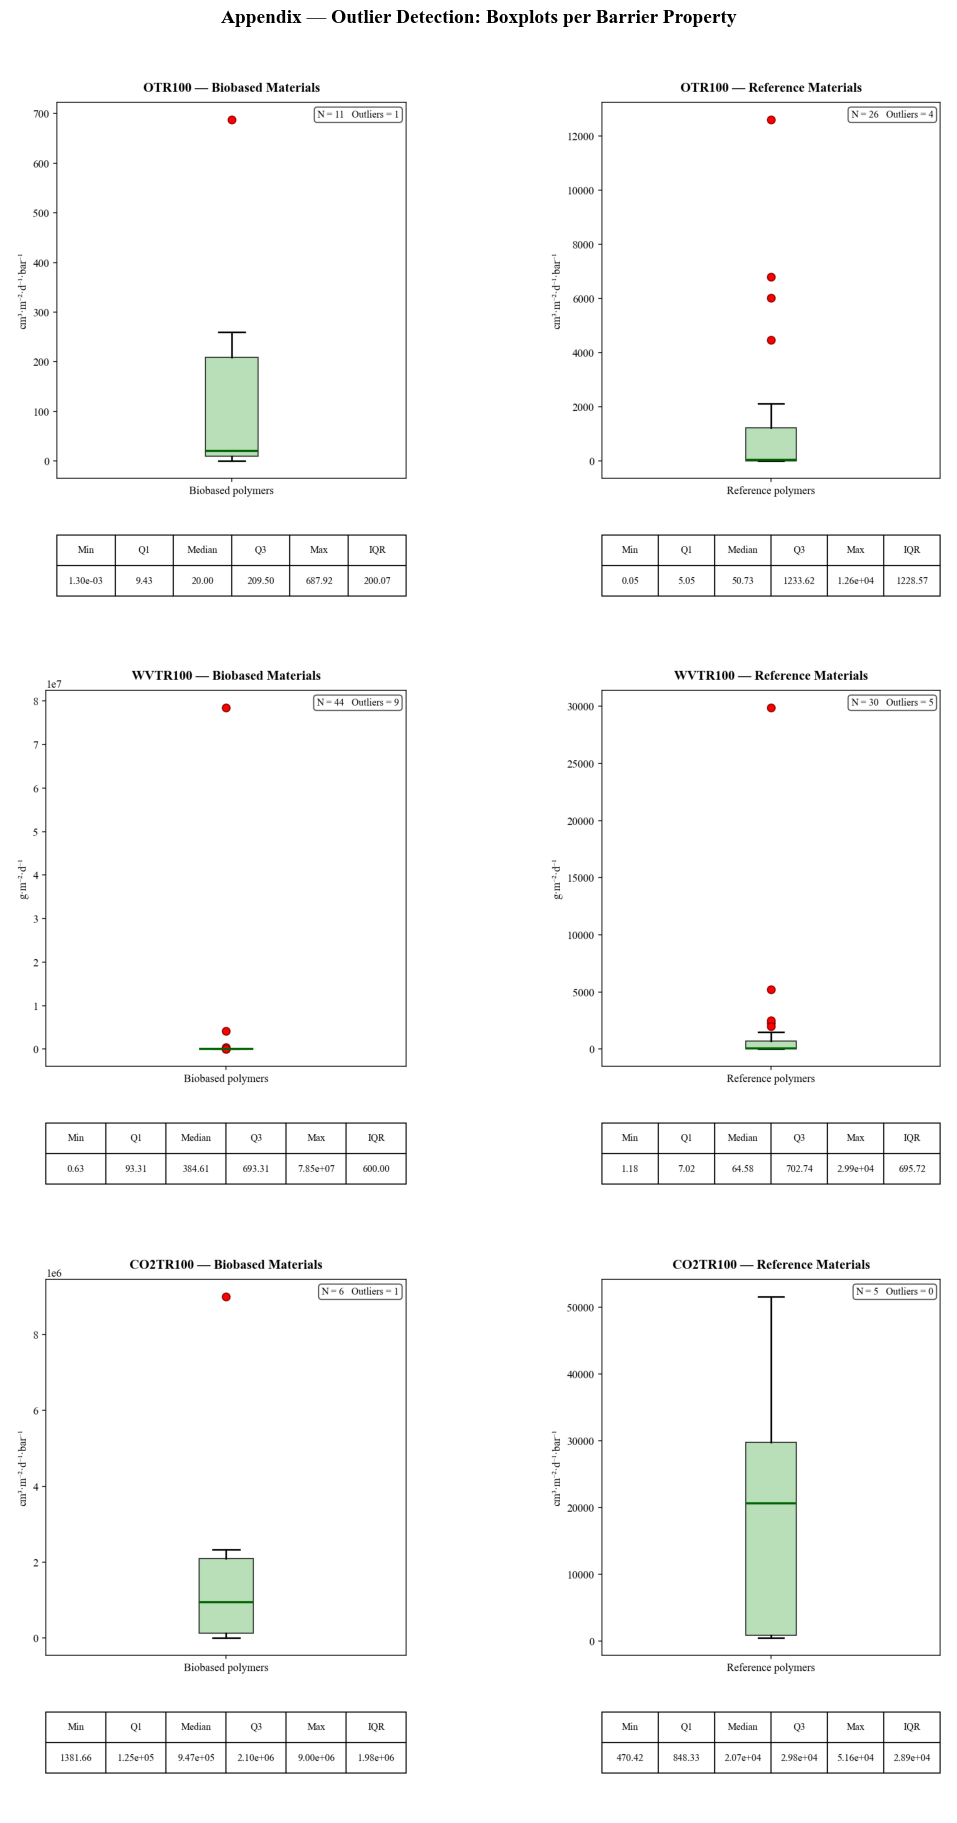

✅ Saved: visualisations_v7/appendix_outlier_boxplots.png


In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

mpl.rcParams['font.family'] = 'Times New Roman'

# Load the 6 saved boxplot images
image_files = [
    ('visualisations_v7/boxplot_OTR100_biobased.png',    'OTR100 — Biobased'),
    ('visualisations_v7/boxplot_OTR100_reference.png',   'OTR100 — Reference'),
    ('visualisations_v7/boxplot_WVTR100_biobased.png',   'WVTR100 — Biobased'),
    ('visualisations_v7/boxplot_WVTR100_reference.png',  'WVTR100 — Reference'),
    ('visualisations_v7/boxplot_CO2TR100_biobased.png',  'CO2TR100 — Biobased'),
    ('visualisations_v7/boxplot_CO2TR100_reference.png', 'CO2TR100 — Reference'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 18))
fig.suptitle('Appendix — Outlier Detection: Boxplots per Barrier Property',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (filepath, label) in zip(axes.flatten(), image_files):
    img = Image.open(filepath)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout(h_pad=2, w_pad=2)

output_path = 'visualisations_v7/appendix_outlier_boxplots.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {output_path}')

In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

os.makedirs('visualisations_v7', exist_ok=True)
mpl.rcParams['font.family'] = 'Times New Roman'

df_bio = df[df['Biobased'] == 'Yes'].copy()
df_ref = df[df['Reference_polymer'].notna()].copy()

plots = [
    ('OTR100_cm3·m-2·d-1·bar-1',            'OTR100 — Biobased Materials',    'cm³·m⁻²·d⁻¹·bar⁻¹', 'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_OTR100_biobased_without_stats.png'),
    ('WVTR100_g·m-2·d-1',                    'WVTR100 — Biobased Materials',   'g·m⁻²·d⁻¹',          'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_WVTR100_biobased_without_stats.png'),
    ('CO2TR100_cm3·m-2·d-1·bar-1',           'CO2TR100 — Biobased Materials',  'cm³·m⁻²·d⁻¹·bar⁻¹', 'Biobased polymers',  df_bio, 'visualisations_v7/boxplot_CO2TR100_biobased_without_stats.png'),
    ('Reference_OTR100_cm³·m⁻²·d⁻¹·bar⁻¹',  'OTR100 — Reference Materials',   'cm³·m⁻²·d⁻¹·bar⁻¹', 'Reference polymers', df_ref, 'visualisations_v7/boxplot_OTR100_reference_without_stats.png'),
    ('Reference_WVTR100_g·m-2·d-1',          'WVTR100 — Reference Materials',  'g·m⁻²·d⁻¹',          'Reference polymers', df_ref, 'visualisations_v7/boxplot_WVTR100_reference_without_stats.png'),
    ('Reference_COTR100_cm³·m⁻²·d⁻¹·bar⁻¹', 'CO2TR100 — Reference Materials', 'cm³·m⁻²·d⁻¹·bar⁻¹', 'Reference polymers', df_ref, 'visualisations_v7/boxplot_CO2TR100_reference_without_stats.png'),
]

for col, title, ylabel, xlabel, df_used, filepath in plots:
    if col not in df_used.columns:
        print(f'⚠️  Column not found: {col}')
        continue

    data = df_used[col].dropna()
    if len(data) < 2:
        print(f'⚠️  Not enough data for: {col}')
        continue

    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()

    fig, ax = plt.subplots(figsize=(5, 6))
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#a8d8a8', alpha=0.8),
               medianprops=dict(color='darkgreen', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               flierprops=dict(marker='o', markerfacecolor='red',
                               markeredgecolor='darkred', markersize=7))

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks([1])
    ax.set_xticklabels([xlabel], fontsize=10)
    ax.text(0.98, 0.98, f'N = {len(data)}   Outliers = {n_out}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'✅ Saved: {filepath}')

print(f'\n📁 All plots saved in: visualisations_v7/')

✅ Saved: visualisations_v7/boxplot_OTR100_biobased_without_stats.png
✅ Saved: visualisations_v7/boxplot_WVTR100_biobased_without_stats.png
✅ Saved: visualisations_v7/boxplot_CO2TR100_biobased_without_stats.png
✅ Saved: visualisations_v7/boxplot_OTR100_reference_without_stats.png
✅ Saved: visualisations_v7/boxplot_WVTR100_reference_without_stats.png
✅ Saved: visualisations_v7/boxplot_CO2TR100_reference_without_stats.png

📁 All plots saved in: visualisations_v7/
